Cleaned data saved to: data/cleaned\Cleaned_Citizen_Reviews.csv


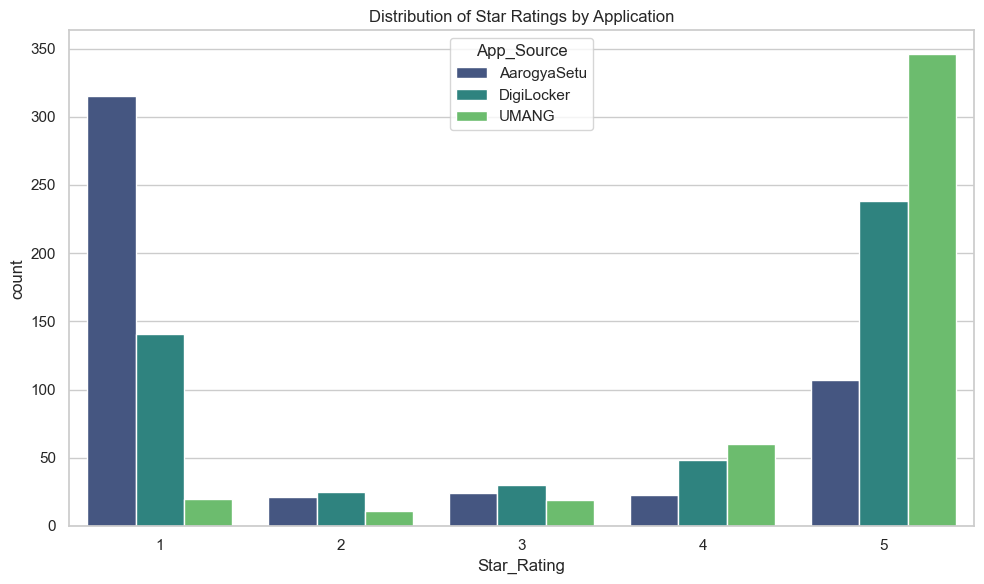

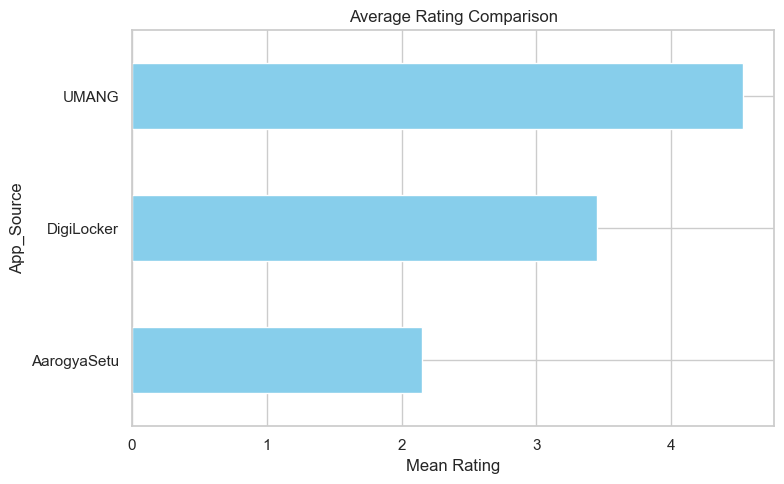

C:\Users\victo\AppData\Local\Temp\ipykernel_23608\291404047.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = app_df.set_index('Timestamp').resample('M').size()


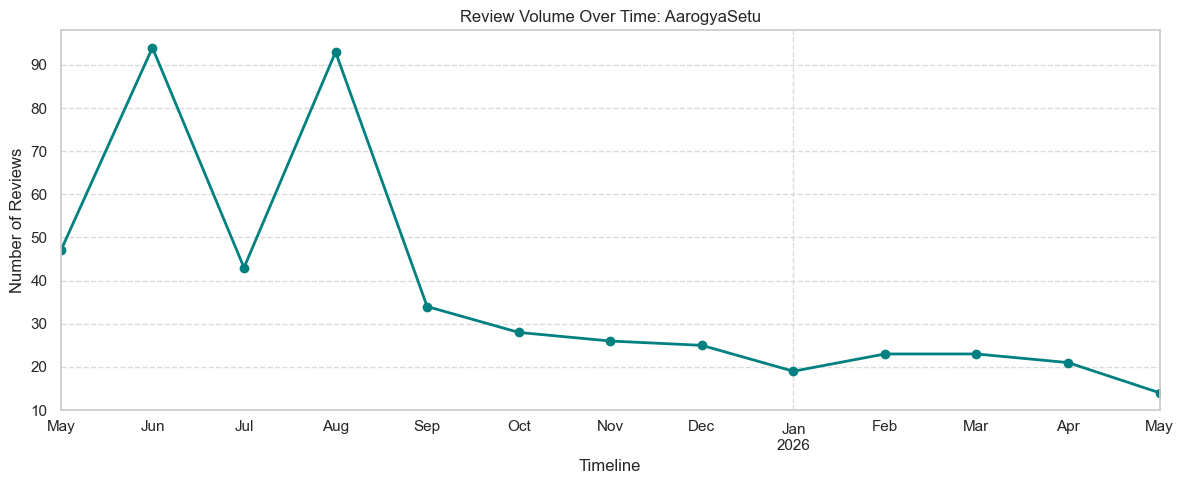

Generating Word Cloud for AarogyaSetu...


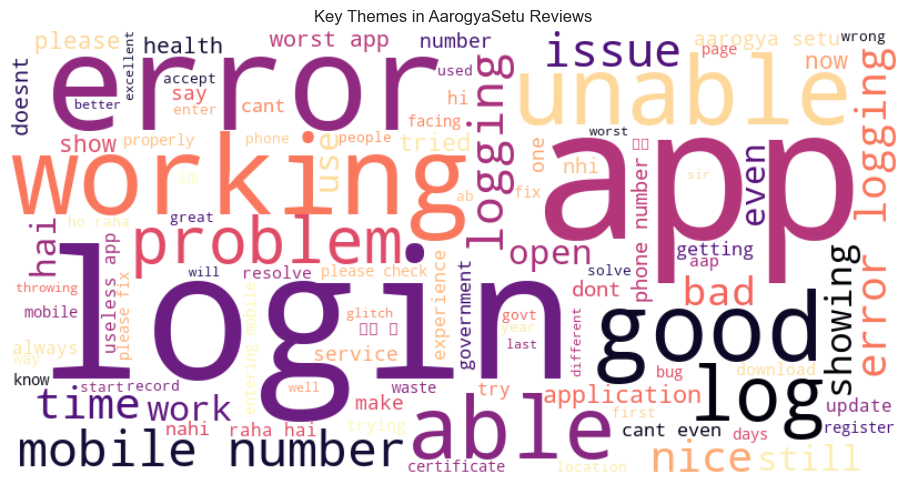

C:\Users\victo\AppData\Local\Temp\ipykernel_23608\291404047.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = app_df.set_index('Timestamp').resample('M').size()


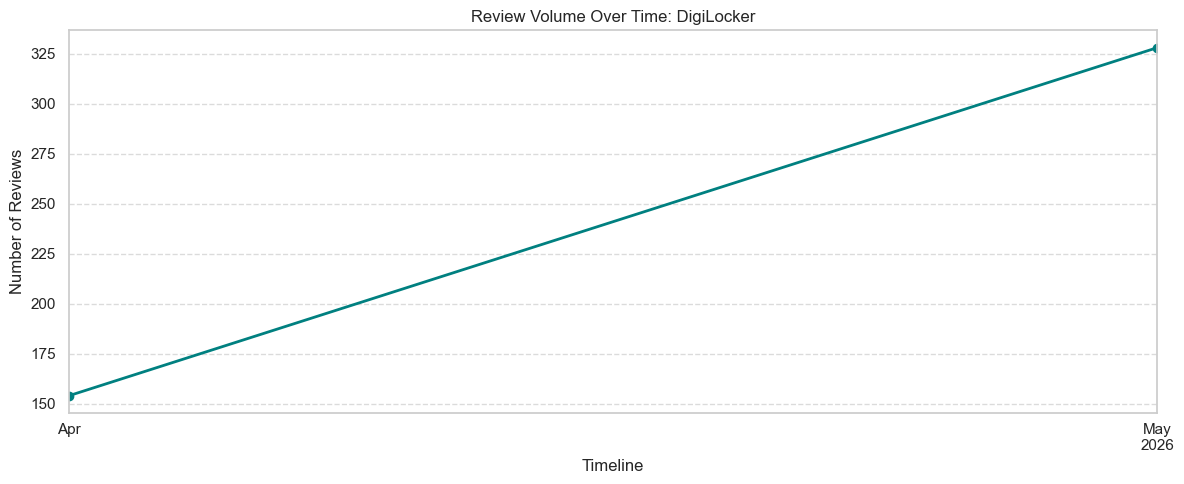

Generating Word Cloud for DigiLocker...


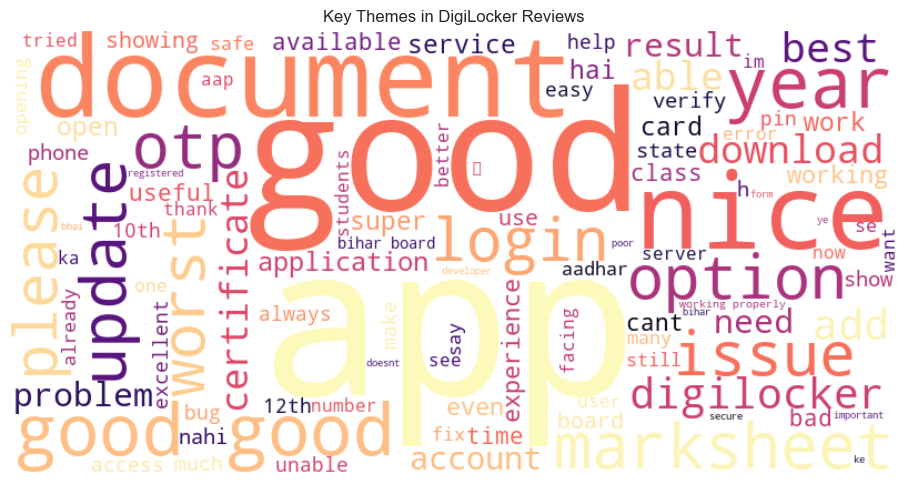

C:\Users\victo\AppData\Local\Temp\ipykernel_23608\291404047.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = app_df.set_index('Timestamp').resample('M').size()
c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


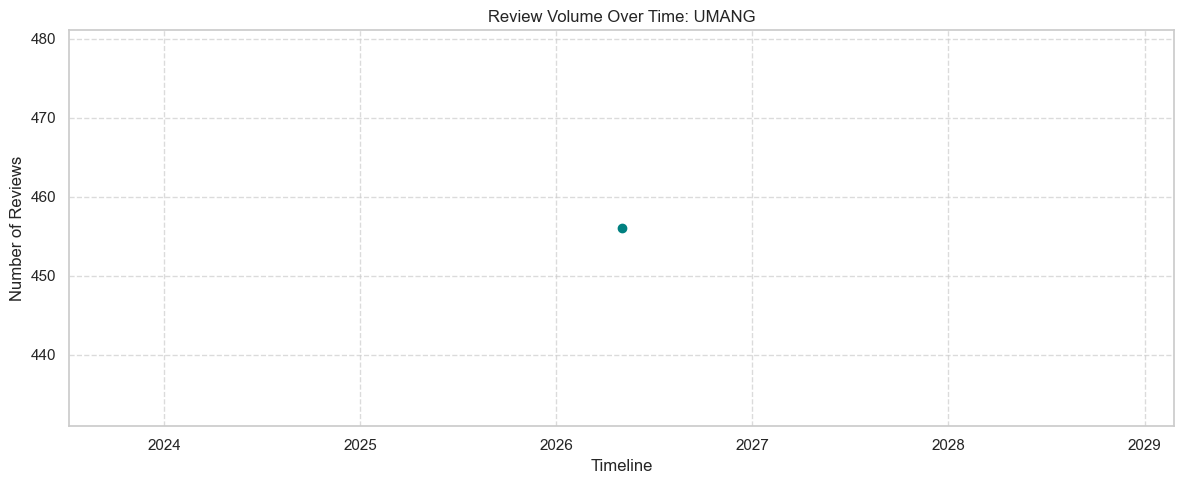

Generating Word Cloud for UMANG...


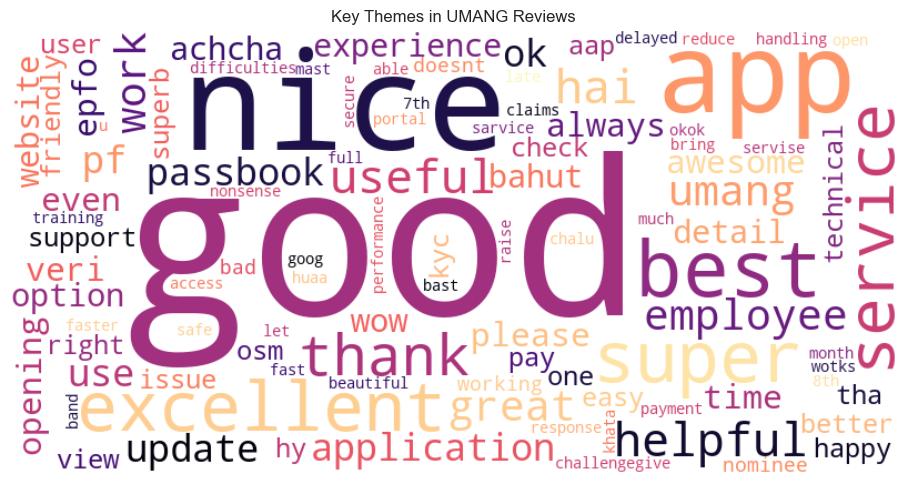

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os
import re

# 1. Setup Directory Structure
folders = ['data/raw', 'data/cleaned', 'data/processed']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

def run_pipeline():
    # 2. Load Raw Data
    raw_path = 'data/raw'
    raw_files = [f for f in os.listdir(raw_path) if f.endswith('.csv')]
    
    if not raw_files:
        print(f"No CSV files found in {raw_path}. Please check your folder.")
        return None

    all_data = []
    for file in raw_files:
        file_path = os.path.join(raw_path, file)
        temp_df = pd.read_csv(file_path)
        # Extract app name from filename for tracking
        temp_df['App_Source'] = file.split('_')[0] 
        all_data.append(temp_df)

    df = pd.concat(all_data, ignore_index=True)

    # 3. Data Cleaning
    df = df.drop_duplicates(subset=['Review_Text', 'Timestamp'])
    df = df.dropna(subset=['Review_Text', 'Star_Rating'])
    
    # Text Normalization
    df['Cleaned_Review'] = df['Review_Text'].astype(str).str.lower()
    df['Cleaned_Review'] = df['Cleaned_Review'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
    
    # Noise Reduction
    df['Cleaned_Review'] = df['Cleaned_Review'].str.strip()
    df = df[df['Cleaned_Review'].str.len() > 2]
    
    # Standardize Timestamps
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp'])

    # 4. Save to data/cleaned
    cleaned_output = os.path.join('data/cleaned', 'Cleaned_Citizen_Reviews.csv')
    df.to_csv(cleaned_output, index=False)
    print(f"Cleaned data saved to: {cleaned_output}")

    # 5. Exploratory Data Analysis (EDA)
    sns.set_theme(style="whitegrid")
    
    # Visualization 1: Rating Counts by App (Aggregated)
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Star_Rating', hue='App_Source', palette='viridis')
    plt.title('Distribution of Star Ratings by Application')
    plt.tight_layout()
    plt.show()

    # Visualization 2: Average Rating per App (Aggregated)
    plt.figure(figsize=(8, 5))
    avg_ratings = df.groupby('App_Source')['Star_Rating'].mean().sort_values()
    avg_ratings.plot(kind='barh', color='skyblue')
    plt.title('Average Rating Comparison')
    plt.xlabel('Mean Rating')
    plt.tight_layout()
    plt.show()

    # --- NEW INDIVIDUAL APP ANALYSES ---
    apps = df['App_Source'].unique()
    
    for app in apps:
        app_df = df[df['App_Source'] == app]
        
        # Individual Review Volume Over Time
        plt.figure(figsize=(12, 5))
        # Resample to monthly volume (M) for clearer trends
        ts_data = app_df.set_index('Timestamp').resample('M').size()
        ts_data.plot(kind='line', marker='o', color='teal', linewidth=2)
        plt.title(f'Review Volume Over Time: {app}')
        plt.ylabel('Number of Reviews')
        plt.xlabel('Timeline')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Individual Word Cloud (Key Themes)
        print(f"Generating Word Cloud for {app}...")
        text_data = " ".join(app_df['Cleaned_Review'].dropna())
        
        if text_data.strip():
            wordcloud = WordCloud(width=800, height=400, 
                                  background_color='white', 
                                  colormap='magma', 
                                  max_words=100).generate(text_data)
            
            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'Key Themes in {app} Reviews')
            plt.tight_layout()
            plt.show()

    return df

# Run the full process
final_df = run_pipeline()

Starting Sentiment Analysis...
Deep analysis complete. File saved to: data/processed\Final_Analytic_Dataset.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_23608\1671569415.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Star_Rating', y='Sentiment_Score', palette='coolwarm')


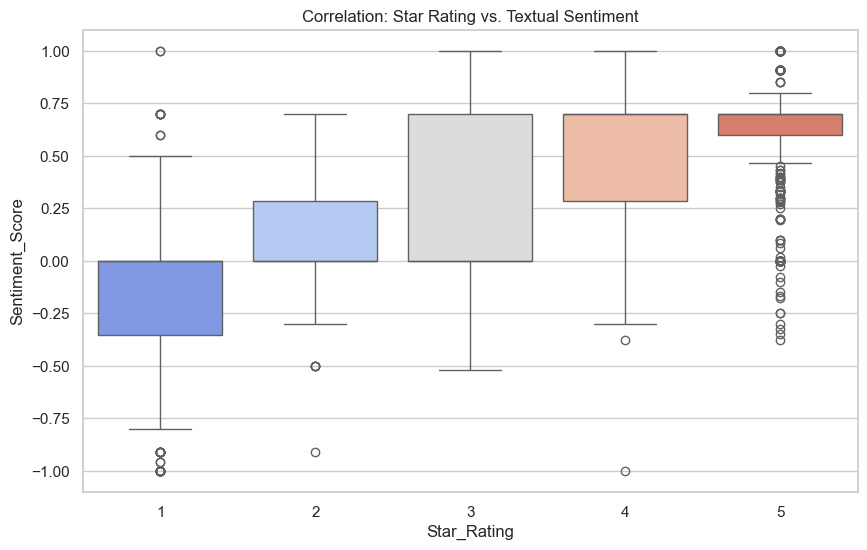

In [45]:
from textblob import TextBlob

def run_advanced_analysis(df):
    print("Starting Sentiment Analysis...")
    
    # 1. Calculate Sentiment Polarity
    df['Sentiment_Score'] = df['Cleaned_Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    
    # 2. Categorize the scores
    df['Sentiment_Label'] = df['Sentiment_Score'].apply(
        lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
    )
    
    # 3. Feature Engineering: Review Length
    df['Review_Length'] = df['Cleaned_Review'].str.len()
    
    # 4. Save the Final Processed Dataset
    processed_path = os.path.join('data/processed', 'Final_Analytic_Dataset.csv')
    df.to_csv(processed_path, index=False)
    print(f"Deep analysis complete. File saved to: {processed_path}")
    
    # 5. Visualization: Sentiment vs Star Rating
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Star_Rating', y='Sentiment_Score', palette='coolwarm')
    plt.title('Correlation: Star Rating vs. Textual Sentiment')
    plt.show()
    
    return df

# To execute, simply call it using your previous final_df
final_df = run_advanced_analysis(final_df)

In [46]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("--- Running Multiple Linear Regression for RQ1 ---")

# Ensure App_Name is treated as a categorical factor variable
# This uses DigiLocker or AarogyaSetu as a baseline and measures the shift for UMANG
model_star = smf.ols(formula="Star_Rating ~ Review_Length + C(App_Name)", data=final_df).fit()
print("\n=== Regression Results: Predicting Star Ratings ===")
print(model_star.summary())

model_sentiment = smf.ols(formula="Sentiment_Score ~ Review_Length + C(App_Name)", data=final_df).fit()
print("\n=== Regression Results: Predicting Sentiment Scores ===")
print(model_sentiment.summary())

--- Running Multiple Linear Regression for RQ1 ---

=== Regression Results: Predicting Star Ratings ===
                            OLS Regression Results                            
Dep. Variable:            Star_Rating   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     242.8
Date:                Sun, 31 May 2026   Prob (F-statistic):          3.08e-127
Time:                        21:31:01   Log-Likelihood:                -2578.5
No. Observations:                1428   AIC:                             5165.
Df Residuals:                    1424   BIC:                             5186.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------


--- Mining Technical & Structural Bottlenecks for RQ3 ---

=== Top 10 Clustered Socio-Technical Friction Points ===
       Phrase  Frequency
 unable login         32
error logging         32
mobile number         31
    worst app         21
   able login         19
  app working         14
  login error         14
showing error         12
 phone number         11
     raha hai         11


C:\Users\victo\AppData\Local\Temp\ipykernel_23608\501466185.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ngram_counts, x='Frequency', y='Phrase', palette='flare')


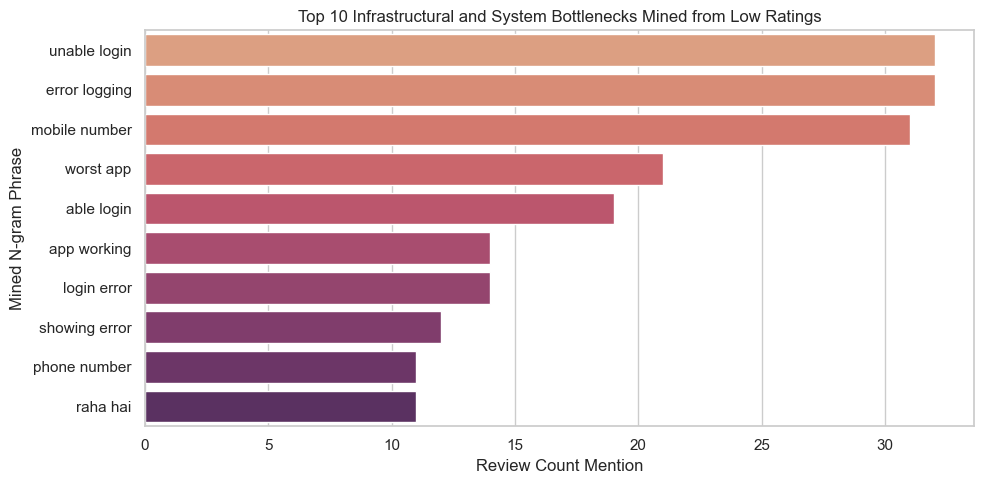

In [47]:
from sklearn.feature_extraction.text import CountVectorizer

print("\n--- Mining Technical & Structural Bottlenecks for RQ3 ---")

# Filter for low-satisfaction reviews
negative_reviews = final_df[final_df['Star_Rating'] <= 2]['Cleaned_Review'].dropna()

# Extract Bigrams (2-word phrases) and Trigrams (3-word phrases)
vectorizer = CountVectorizer(ngram_range=(2, 3), stop_words='english', max_features=10)
ngram_matrix = vectorizer.fit_transform(negative_reviews)

# Summarize counts
ngram_counts = pd.DataFrame({
    'Phrase': vectorizer.get_feature_names_out(),
    'Frequency': ngram_matrix.toarray().sum(axis=0)
}).sort_values(by='Frequency', ascending=False)

print("\n=== Top 10 Clustered Socio-Technical Friction Points ===")
print(ngram_counts.to_string(index=False))

# Plot the bottlenecks
plt.figure(figsize=(10, 5))
sns.barplot(data=ngram_counts, x='Frequency', y='Phrase', palette='flare')
plt.title('Top 10 Infrastructural and System Bottlenecks Mined from Low Ratings')
plt.xlabel('Review Count Mention')
plt.ylabel('Mined N-gram Phrase')
plt.tight_layout()
plt.show()

In [48]:
print("\n--- Validating Localized Language Performance for RQ4 ---")

# Quick count of reviews categorized as Neutral despite extreme ratings
mismatched_neutral = final_df[
    (final_df['Sentiment_Label'] == 'Neutral') & 
    ((final_df['Star_Rating'] == 1) | (final_df['Star_Rating'] == 5))
]

print(f"Total reviews flagged as Neutral despite 1 or 5-Star explicit ratings: {len(mismatched_neutral)}")
print("\nSample of localized / code-switched phrases causing Lexicon blind spots:")
print(mismatched_neutral[['App_Name', 'Review_Text', 'Star_Rating', 'Sentiment_Score']].head(5))


--- Validating Localized Language Performance for RQ4 ---
Total reviews flagged as Neutral despite 1 or 5-Star explicit ratings: 326

Sample of localized / code-switched phrases causing Lexicon blind spots:
       App_Name                                        Review_Text  \
0   AarogyaSetu                                  app login problem   
6   AarogyaSetu                                           nor work   
7   AarogyaSetu                                       Cannot login   
10  AarogyaSetu  It's almost been 3.5 years Since Pandemic went...   
11  AarogyaSetu                                        all is well   

    Star_Rating  Sentiment_Score  
0             1              0.0  
6             1              0.0  
7             1              0.0  
10            1              0.0  
11            5              0.0  


In [49]:
import statsmodels.formula.api as smf

print("=== Running Multiple Linear Regression for RQ1 ===")
# Predict Star Ratings
model_star = smf.ols(formula="Star_Rating ~ Review_Length + C(App_Name)", data=final_df).fit()
print(model_star.summary())

# Predict Continuous Sentiment Scores
model_sentiment = smf.ols(formula="Sentiment_Score ~ Review_Length + C(App_Name)", data=final_df).fit()
print(model_sentiment.summary())

=== Running Multiple Linear Regression for RQ1 ===
                            OLS Regression Results                            
Dep. Variable:            Star_Rating   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     242.8
Date:                Sun, 31 May 2026   Prob (F-statistic):          3.08e-127
Time:                        21:31:01   Log-Likelihood:                -2578.5
No. Observations:                1428   AIC:                             5165.
Df Residuals:                    1424   BIC:                             5186.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [50]:
from sklearn.feature_extraction.text import CountVectorizer

print("\n=== Mining Structural Bottlenecks from Low Ratings (RQ3) ===")
# Isolate poor reviews
negative_reviews = final_df[final_df['Star_Rating'] <= 2]['Cleaned_Review'].dropna()

# Extract top 2 and 3-word phrases
vectorizer = CountVectorizer(ngram_range=(2, 3), stop_words='english', max_features=10)
ngram_matrix = vectorizer.fit_transform(negative_reviews)

ngram_counts = pd.DataFrame({
    'Phrase': vectorizer.get_feature_names_out(),
    'Frequency': ngram_matrix.toarray().sum(axis=0)
}).sort_values(by='Frequency', ascending=False)

print(ngram_counts.to_string(index=False))


=== Mining Structural Bottlenecks from Low Ratings (RQ3) ===
       Phrase  Frequency
 unable login         32
error logging         32
mobile number         31
    worst app         21
   able login         19
  app working         14
  login error         14
showing error         12
 phone number         11
     raha hai         11


In [51]:
print("\n=== Quantifying Lexicon Blind Spots for Localized Language (RQ4) ===")
# Find 1 or 5 star reviews that VADER marked completely neutral (0.0) due to language mixing
mismatched = final_df[(final_df['Sentiment_Score'] == 0.0) & ((final_df['Star_Rating'] == 1) | (final_df['Star_Rating'] == 5))]
print(f"Total localized/code-switched reviews flagged as dead Neutral: {len(mismatched)}")
print(mismatched[['App_Name', 'Review_Text', 'Star_Rating']].head(3))


=== Quantifying Lexicon Blind Spots for Localized Language (RQ4) ===
Total localized/code-switched reviews flagged as dead Neutral: 293
      App_Name        Review_Text  Star_Rating
0  AarogyaSetu  app login problem            1
6  AarogyaSetu           nor work            1
7  AarogyaSetu       Cannot login            1
